<a href="https://colab.research.google.com/github/Laurasgrv-colab/PRe/blob/main/CaseStudy3_bayesian_logistic_regression_SOUL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study : Bayesian logistic regression via SOUL

This notebook includes my implementation of the SOUL algorithm and its result comparison to the Bayesian logistic regression example in Section 3.1 of [Particle algorithms for maximum likelihood training of latent variable models](https://juankuntz.github.io/publication/parem/).  

In [43]:
import numpy as np
import matplotlib.pyplot as plt

#@title Load modules.

# Install the wget package on Colab (if running the notebook locally,
# comment the following line out).
!pip install wget

# OS and wget to load dataset.
import os
import wget
from scipy.stats import norm


We load the same dataset in order to compare results and verify the correctness of our function.

In [44]:
#@title Load and normalize the Wisconsin Breast Cancer dataset.

# Fetch dataset from repository:
wget.download('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data')

# Load dataset:
dataset = np.loadtxt('breast-cancer-wisconsin.data', dtype=str, delimiter=',')

# Delete local copy of dataset to avoid duplicates with multiple notebook runs:
os.remove('breast-cancer-wisconsin.data')

# Remove datapoints with missing attributes and change dtype to float:
dataset = dataset[~(dataset == '?').any(axis=1), :].astype(float)

# Extract features and labels, and normalize features:
features = np.array(dataset[:, 1:10] - dataset[:, 1:10].mean(0))
features = features/features.std(0)
labels = np.array([(dataset[:, 10]-2)/2]).transpose()

This is my SOUL function.

In [52]:
def soul(log_p_grad_x, th0, x0_M, y_l, y_f, T, M, B, delta_step, gamma_step):
  """
    Stochastic Optimisation via Unadjusted Langevin (SOUL).

    Parameters:
    - log_p_grad_x: Function returning grad_x log p(th, X, y). Shape matches X.
    - log_p_grad_th: Function returning grad_theta log p(th, X, y). Shape matches theta.
    - th_0: Initial parameters
    - x0_M: Initial latent variables from the previous step
    - y: Observed data
    - T: Number of outer optimization steps
    - M: Number of Langevin steps
    - B: Burn-in steps
    - delta_step: Step size for theta update
    - gamma_step: Langevin step size
    """
  th = np.copy(th0)
  x_t = np.copy(x0_M[:, 0:1]).reshape(D,1) # shape (D,1) (instead of (D,)) - keeps the column dimension

  x_values = np.array(x0_M)
  th_list = [th0]
  for t in range(1, T+1):

    # ULA steps
    for m in range(1, M+1):
      grad_x = log_p_grad_x(th, x_t, y_l, y_f)
      Z_k = np.random.normal(0.0, 1.0, x_t.shape) # Force size

      # Compute new x
      x_t += gamma_step * grad_x + np.sqrt(2.0 * gamma_step) * Z_k
      x_values = np.append(x_values, np.copy(x_t), axis=1) # Store new position

    burnin_x_samples = x_values[:, -(M-B):] # Shape (D, M-B)

    # Compute new theta
    avg_grad_th = np.zeros_like(th) # th is (1,1), so avg_grad_th is (1,1)

    # Iterate over particles (columns) instead of feature dimensions (rows)
    for idx in range(M-B):
      x_m_burnin = burnin_x_samples[:, idx:idx+1] # Shape (D,1)
      # (x_m_burnin - th) will broadcast to (D, 1).
      # We first sum only along D with .sum(0), then average over M-B.
      avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

    th = th + delta_step * avg_grad_th /(M-B) # Update theta
    th_list.append(np.copy(th)) # Store new theta

  return th_list, x_values

And this is the gradient function specific to the problem.

In [46]:
def log_p_grad_x(th, x, y_l, y_f):
  s = 1/(1+np.exp(- np.matmul(y_f, x)))
  return np.matmul((y_l-s).transpose(), y_f).transpose() - (x-th)/5


# Figure 3a

Let's run the algorithm on 80/20 split of the data and plot the results.

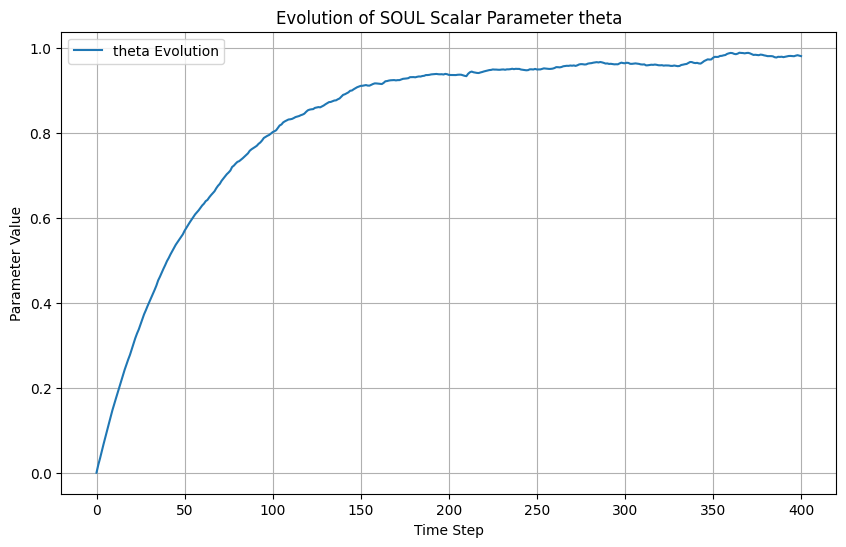

In [53]:
# Split data into 80/20 training and testing sets:
from sklearn.model_selection import train_test_split
ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2,
                                                random_state=0)

# Set approximation parameters as in our reference paper:
delta_step = 1e-2 # Step-size, same for ULA and Langevin in this case.
gamma_step = 1e-2
T = 400  # Number of steps.
M = 100  # Number of particles.
B = 0 # There is no burn-in in this example.

# Initialize parameter estimates and particle cloud, all at zero:
D = features[0, :].size  # Dimension of latent space.
th0 = np.array([0.0])  # Parameter estimate, initialized as a (1,1) float array (scalar).
x0 = np.zeros((D, M))  # Particle cloud.

# Run algorithm:
th_soul, x_soul = soul(log_p_grad_x, th0, x0, ltrain, ftrain, T, M, B, delta_step, gamma_step)

# Plot the results
plt.figure(figsize=(10, 6))

plt.plot(th_soul, label='theta Evolution')
plt.xlabel('Time Step')
plt.ylabel('Parameter Value')
plt.title('Evolution of SOUL Scalar Parameter theta')
plt.legend()
plt.grid(True)
plt.show()

In [48]:

print(len(x0[:, 0:1][1]))
#x_list = np.zeros((D, 1))
x_list = np.array(x0[:, 0:1])
print(x_list)
print(x_list.shape)
print("----------")
print(len(x_list))
print(len(x_list[0]))



1
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
(9, 1)
----------
9
1


# Figure 3b

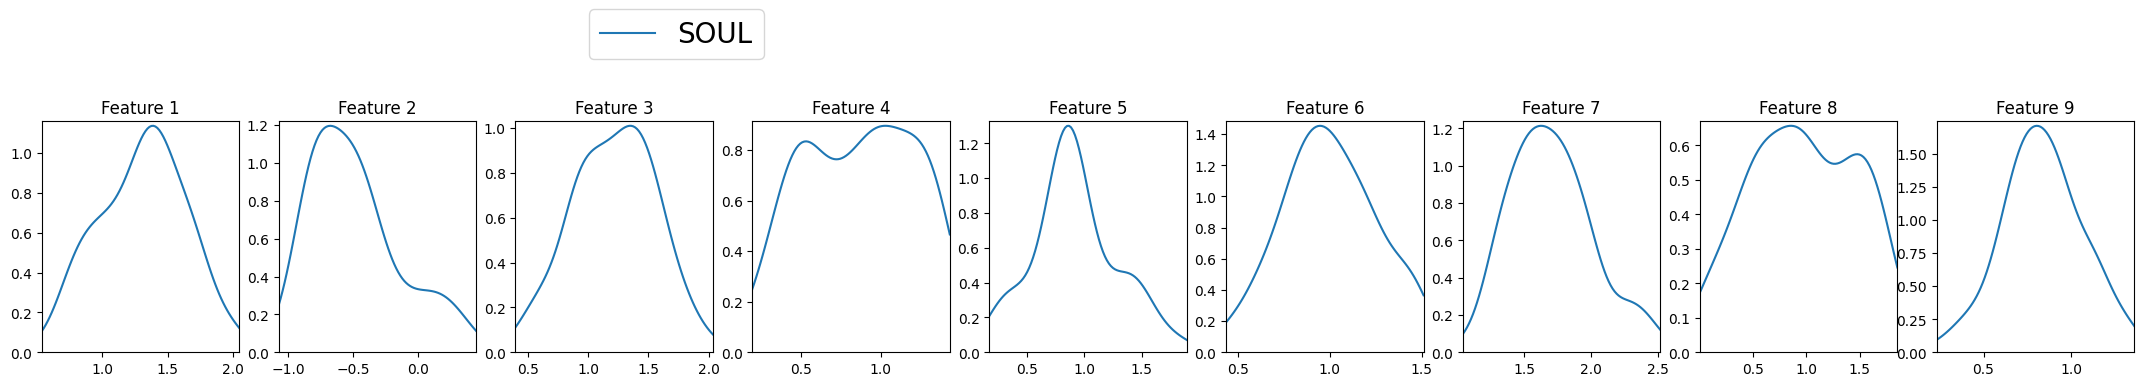

In [54]:
# Extract final particle clouds X^{1:N}_K:
q_soul = x_soul[:, -M:]

# Generate and plot KDEs:
from scipy import stats  # stats to generate KDEs.
fig = plt.figure(figsize=(27,3), dpi= 100)
for i in range(D):
    # Generate KDEs for ith entry of the final particle cloud X^{1:N}_K:
    kde_min = np.min([ q_soul[i, :]])
    kde_max = np.max([ q_soul[i, :]])
    kde_g = [0, -2, -2, -1, -1, 0, 0, 0, 0]
    kde_d = [2.5, 2.5, 2.5, 2.5, 2, 3.5, 2.5, 2.5, 2.5]
    xaxis = np.linspace(kde_min, kde_max, num=100)

    kde_soul = stats.gaussian_kde(q_soul[i, :])(xaxis)

    # Plot KDEs:
    plt.subplot(1, D, i+1)
    plt.plot(xaxis, kde_soul, label='SOUL')
    plt.title('Feature ' + str(i+1))
    plt.ylim([0, 1.02*np.max([kde_soul])])
    plt.xlim([kde_min, kde_max])


handles, figlabels = plt.gca().get_legend_handles_labels()
fig.legend(handles, figlabels, ncol=4, bbox_to_anchor=(0.36,1.3),
           loc="upper center",fontsize=20)
plt.subplots_adjust(hspace=0.6)

# Figure 3c


In [64]:
th0 = np.array([10.]) # Float
x0 = 10*np.ones((D, M))


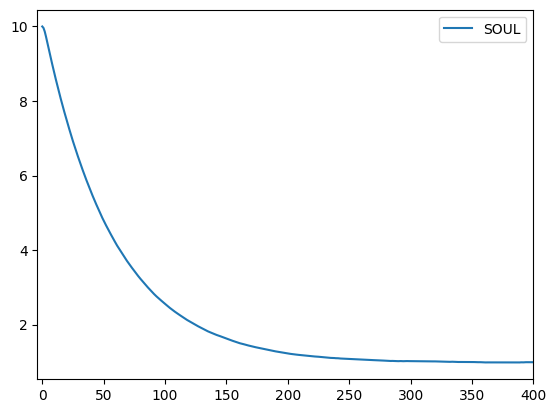

In [65]:
# Re-run algorithm:
th_soul, x_soul = soul(log_p_grad_x, th0, x0, ltrain, ftrain, T, M, B, delta_step, gamma_step)


# Plot parameter estimates:
plt.plot(th_soul, label='SOUL')
plt.xlim([-T/100, T])
plt.legend(loc='upper right')